In [1]:
import optuna
import numpy as np
import pandas as pd

optuna.logging.set_verbosity(optuna.logging.WARNING)
import matplotlib.pyplot as plt
import seaborn as sns


import gc
gc.collect()

# Display Markdown
from IPython.display import display, Markdown

import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)

display(Markdown("### <span style='color:#27AE60; font-weight:bold;font-size:24px; text-shadow:0 0 3px rgba(15,52,96,0.6);'>Libraries Loaded!</span>"))

C:\Users\roton\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### <span style='color:#27AE60; font-weight:bold;font-size:24px; text-shadow:0 0 3px rgba(15,52,96,0.6);'>Libraries Loaded!</span>

In [2]:
data_path    = "D:/Education/AiQuest/DS,ML,DL/Projects/House Price Prediction/data/USA_Housing.csv"
data= pd.read_csv(data_path)

display(Markdown("## <span style='color:#27AE60; font-weight:bold;font-size:24px; text-shadow:0 0 3px rgba(15,52,96,0.6);'>Data Loaded</span>"))

## <span style='color:#27AE60; font-weight:bold;font-size:24px; text-shadow:0 0 3px rgba(15,52,96,0.6);'>Data Loaded</span>

In [3]:
display(Markdown(f"**Rows:** {data.shape[0]}, **Columns:** {data.shape[1]}"))
display(data.head(3))

**Rows:** 5000, **Columns:** 7

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."


# <h2 style= 'text-align:center; color:#27AE60; font-weight:bold;font-size:40px;  text-shadow:0 0 3px rgba(15,52,96,0.6);'>Data Overview!</h2>

In [4]:
display(Markdown("### <span style='color:#27AE60; font-weight:bold; font-size:24px; text-shadow:0 0 3px rgba(15,52,96,0.6);'>First 5 Rows</span>"))
display(data.head())

### <span style='color:#27AE60; font-weight:bold; font-size:24px; text-shadow:0 0 3px rgba(15,52,96,0.6);'>First 5 Rows</span>

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386


In [5]:
display(Markdown("### <span style='color:#27AE60; font-weight:bold; font-size:24px; text-shadow:0 0 3px rgba(15,52,96,0.6);'>Shape of the Dataset</span>"))
display(Markdown(f"**Rows:** {data.shape[0]}, **Columns:** {data.shape[1]}"))

### <span style='color:#27AE60; font-weight:bold; font-size:24px; text-shadow:0 0 3px rgba(15,52,96,0.6);'>Shape of the Dataset</span>

**Rows:** 5000, **Columns:** 7

In [6]:
display(Markdown("### <span style='color:#27AE60; font-weight:bold;font-size:24px; text-shadow:0 0 3px rgba(15,52,96,0.6);'>Data Types</span>"))
display(data.dtypes)

### <span style='color:#27AE60; font-weight:bold;font-size:24px; text-shadow:0 0 3px rgba(15,52,96,0.6);'>Data Types</span>

Avg. Area Income                float64
Avg. Area House Age             float64
Avg. Area Number of Rooms       float64
Avg. Area Number of Bedrooms    float64
Area Population                 float64
Price                           float64
Address                             str
dtype: object

In [7]:
display(Markdown("### <span style='color:#27AE60; font-weight:bold;font-size:24px; text-shadow:0 0 3px rgba(15,52,96,0.6);'>Missing Values</span>"))
display(data.isnull().sum().sort_values(ascending=False))

### <span style='color:#27AE60; font-weight:bold;font-size:24px; text-shadow:0 0 3px rgba(15,52,96,0.6);'>Missing Values</span>

Avg. Area Income                0
Avg. Area House Age             0
Avg. Area Number of Rooms       0
Avg. Area Number of Bedrooms    0
Area Population                 0
Price                           0
Address                         0
dtype: int64

In [8]:
display(Markdown("### <span style='color:#27AE60; font-weight:bold; font-size:24px;text-shadow:0 0 3px rgba(15,52,96,0.6);'>Duplicate Rows</span>"))
display(Markdown(f"**Total Duplicates:** {data.duplicated().sum()}"))

### <span style='color:#27AE60; font-weight:bold; font-size:24px;text-shadow:0 0 3px rgba(15,52,96,0.6);'>Duplicate Rows</span>

**Total Duplicates:** 0

In [9]:
display(Markdown("### <span style='color:#27AE60; font-weight:bold; font-size:24px;text-shadow:0 0 3px rgba(15,52,96,0.6);'>Dataset Info</span>"))
display(Markdown(f"**Total Duplicates:** {data.info()}"))

### <span style='color:#27AE60; font-weight:bold; font-size:24px;text-shadow:0 0 3px rgba(15,52,96,0.6);'>Dataset Info</span>

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Avg. Area Income              5000 non-null   float64
 1   Avg. Area House Age           5000 non-null   float64
 2   Avg. Area Number of Rooms     5000 non-null   float64
 3   Avg. Area Number of Bedrooms  5000 non-null   float64
 4   Area Population               5000 non-null   float64
 5   Price                         5000 non-null   float64
 6   Address                       5000 non-null   str    
dtypes: float64(6), str(1)
memory usage: 499.6 KB


**Total Duplicates:** None

In [10]:
display(Markdown("### <span style='color:#27AE60; font-weight:bold; font-size:24px;text-shadow:0 0 3px rgba(15,52,96,0.6);'>Unique Count</span>"))
display(data.nunique().sort_values(ascending=False))

### <span style='color:#27AE60; font-weight:bold; font-size:24px;text-shadow:0 0 3px rgba(15,52,96,0.6);'>Unique Count</span>

Avg. Area Income                5000
Avg. Area House Age             5000
Avg. Area Number of Rooms       5000
Area Population                 5000
Price                           5000
Address                         5000
Avg. Area Number of Bedrooms     255
dtype: int64

In [11]:
display(Markdown("## <span style='color:#27AE60; font-weight:bold; font-size:24px; font-size:24px;text-shadow:0 0 5px rgba(15,52,96,0.6);'>Separate Categorical & Numerical Columns</span>"))

categorical_cols = data.select_dtypes(include=['object']).columns.tolist()
numerical_cols = data.select_dtypes(include=['int64', 'float64']).columns.tolist()

## <span style='color:#27AE60; font-weight:bold; font-size:24px; font-size:24px;text-shadow:0 0 5px rgba(15,52,96,0.6);'>Separate Categorical & Numerical Columns</span>

In [12]:
display(Markdown("### <span style='color:#27AE60; font-weight:bold;font-size:24px; text-shadow:0 0 3px rgba(15,52,96,0.6);'>Categorical Columns</span>"))
display(categorical_cols)

display(Markdown("### <span style='color:#27AE60; font-weight:bold;font-size:24px; text-shadow:0 0 3px rgba(15,52,96,0.6);'>Numerical Columns</span>"))
display(numerical_cols)

### <span style='color:#27AE60; font-weight:bold;font-size:24px; text-shadow:0 0 3px rgba(15,52,96,0.6);'>Categorical Columns</span>

['Address']

### <span style='color:#27AE60; font-weight:bold;font-size:24px; text-shadow:0 0 3px rgba(15,52,96,0.6);'>Numerical Columns</span>

['Avg. Area Income',
 'Avg. Area House Age',
 'Avg. Area Number of Rooms',
 'Avg. Area Number of Bedrooms',
 'Area Population',
 'Price']

# <h2 style= 'text-align:center; color:#27AE60; font-weight:bold;font-size:40px;  text-shadow:0 0 3px rgba(15,52,96,0.6);'>Target Variable Analysis!</h2>

In [13]:
display(Markdown("### <span style='color:#27AE60; font-weight:bold;font-size:24px; text-shadow:0 0 3px rgba(15,52,96,0.6);'>Numerical Stats</span>"))

display(data.describe().round(3))

### <span style='color:#27AE60; font-weight:bold;font-size:24px; text-shadow:0 0 3px rgba(15,52,96,0.6);'>Numerical Stats</span>

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
count,5000.000,5000.000,5000.000,5000.000,5000.000,5000.000
mean,68583.109,5.977,6.988,3.981,36163.516,1232072.654
std,10657.991,0.991,1.006,1.234,9925.650,353117.627
min,17796.631,2.644,3.236,2.000,172.611,15938.658
25%,61480.562,5.322,6.299,3.140,29403.929,997577.135
50%,68804.286,5.970,7.003,4.050,36199.407,1232669.378
75%,75783.339,6.651,7.666,4.490,42861.291,1471210.204
max,107701.748,9.519,10.760,6.500,69621.713,2469065.594


### <span style='color:#27AE60; font-weight:bold;font-size:24px; text-shadow:0 0 3px rgba(15,52,96,0.6);'>Histogram of Target Columns (Price)</span>

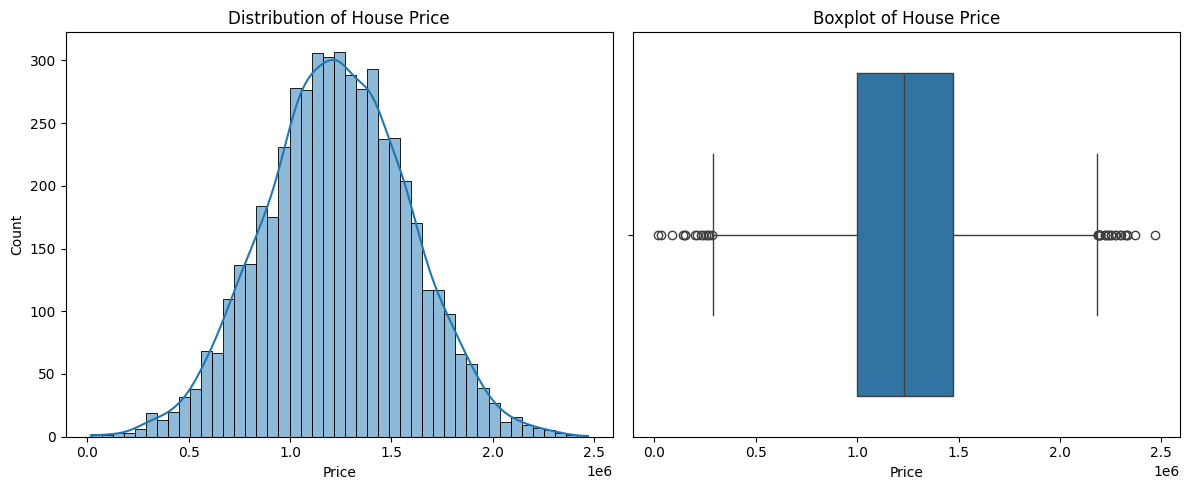

Skewness: -0.002718064933559366


In [14]:
display(Markdown("### <span style='color:#27AE60; font-weight:bold;font-size:24px; text-shadow:0 0 3px rgba(15,52,96,0.6);'>Histogram of Target Columns (Price)</span>"))

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(data['Price'], kde=True)
plt.title('Distribution of House Price')

plt.subplot(1,2,2)
sns.boxplot(x=data['Price'])
plt.title('Boxplot of House Price')

plt.tight_layout()
plt.show()

print("Skewness:", data['Price'].skew())

# <h2 style= 'text-align:center; color:#27AE60; font-weight:bold;font-size:40px;  text-shadow:0 0 3px rgba(15,52,96,0.6);'>Feature Distributions!</h2>

### <span style='color:#27AE60; font-weight:bold;font-size:24px; text-shadow:0 0 3px rgba(15,52,96,0.6);'>Histogram of Numerical Columns</span>

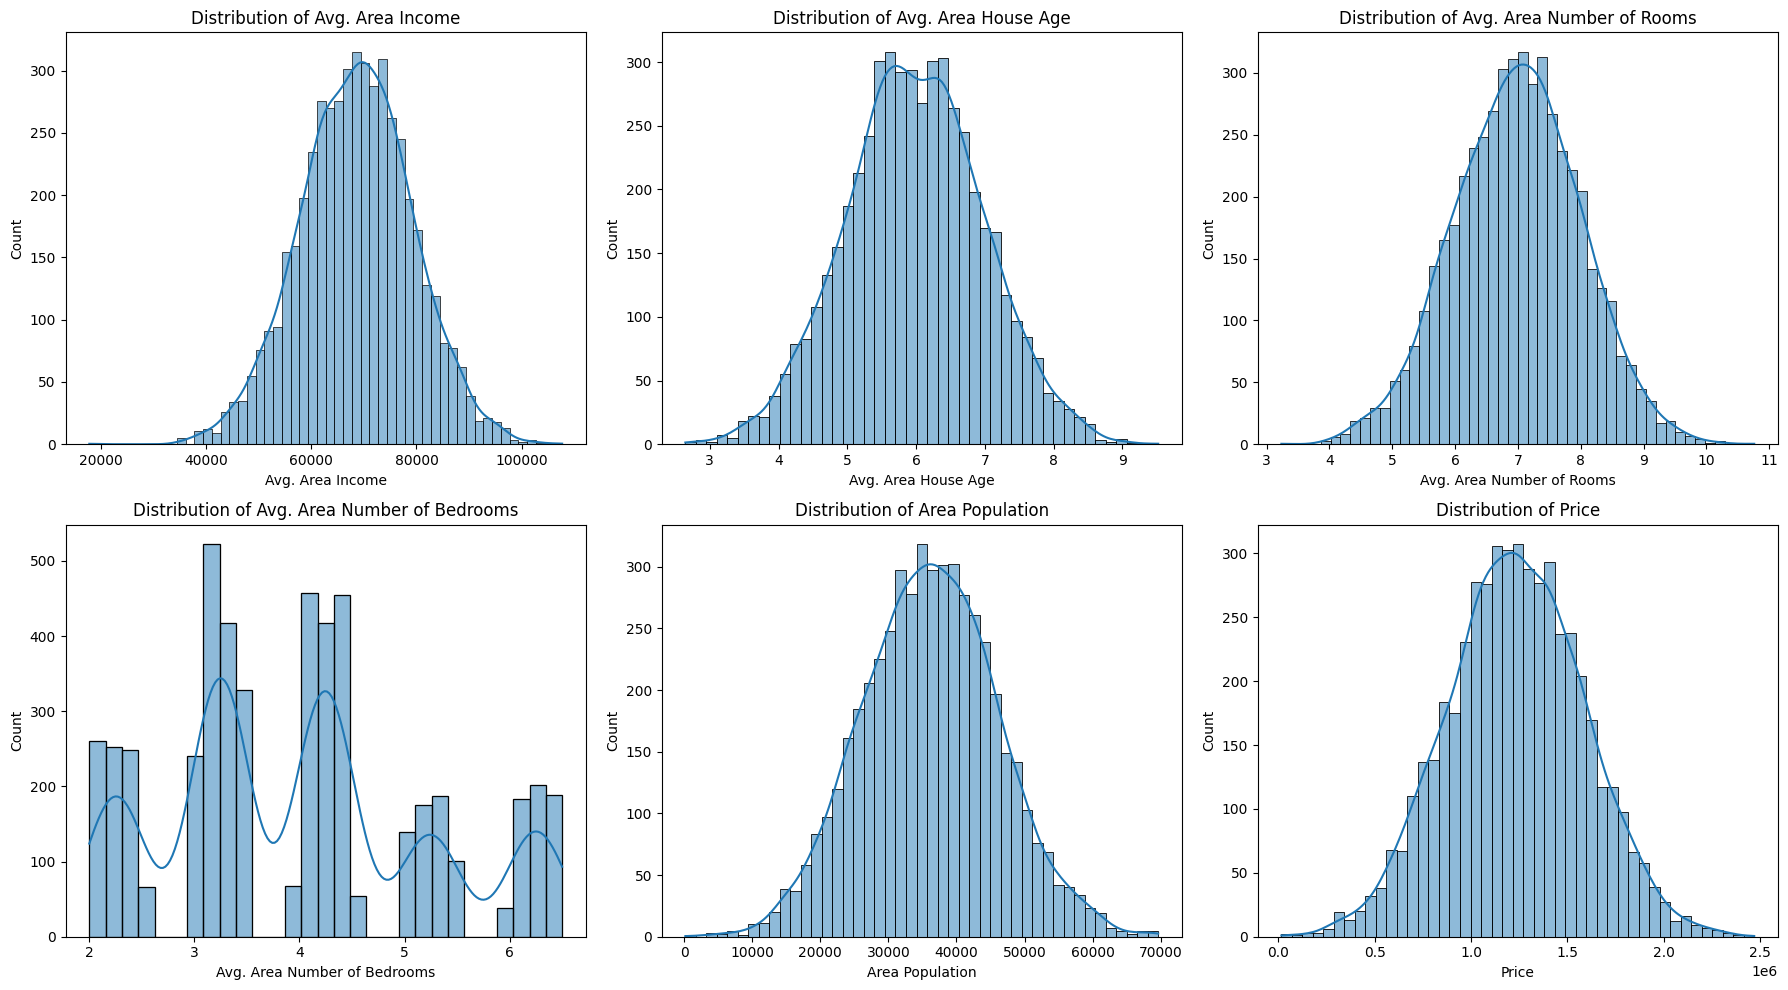

In [15]:
display(Markdown("### <span style='color:#27AE60; font-weight:bold;font-size:24px; text-shadow:0 0 3px rgba(15,52,96,0.6);'>Histogram of Numerical Columns</span>"))

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.histplot(
        data[col],
        kde=True,
        ax=axes[i]
    )
    axes[i].set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

### <span style='color:#27AE60; font-weight:bold;font-size:24px; text-shadow:0 0 3px rgba(15,52,96,0.6);'>Boxplot of Numerical Columns</span>

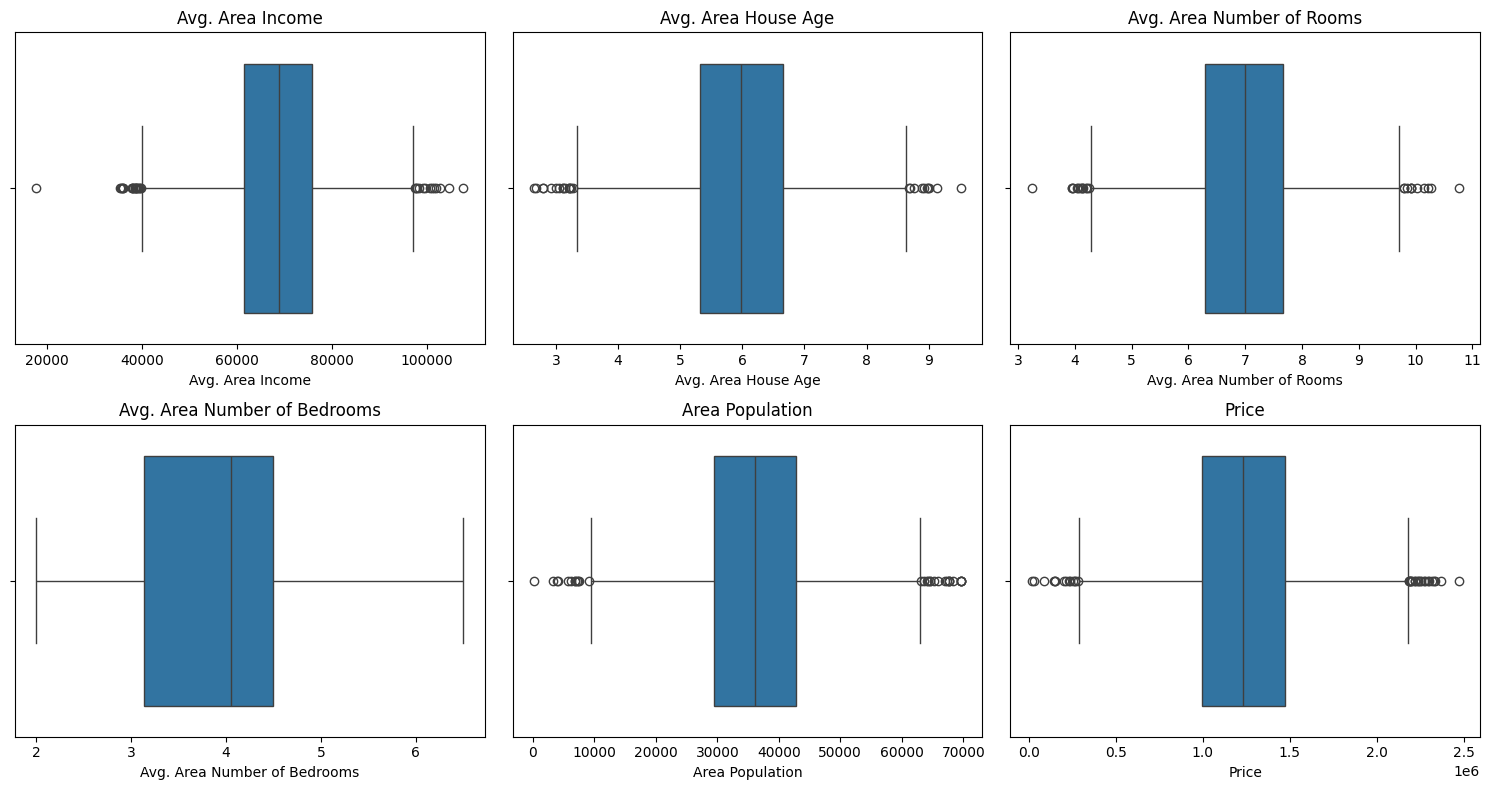

In [16]:
display(Markdown("### <span style='color:#27AE60; font-weight:bold;font-size:24px; text-shadow:0 0 3px rgba(15,52,96,0.6);'>Boxplot of Numerical Columns</span>"))

plt.figure(figsize=(15, 8))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x=data[col])
    plt.title(col)

plt.tight_layout()
plt.show()

<span style='color:#27AE60; font-weight:bold;font-size:24px; text-shadow:0 0 3px rgba(15,52,96,0.6);'>Key Findings from the Dataset (Based on Histograms and Boxplots)</span>

- The dataset contains 5,000 records with no missing values in any feature.
- Most numerical features ( Income, House Age, Number of Rooms, Area Population, and Price) follow an approximately normal distribution.
- The target variable (Price) is relatively symmetric and does not exhibit severe skewness, making it suitable for regression modeling.
- The median values of most features are located near the center of their distributions, indicating balanced data.
- Boxplots reveal the presence of a few outliers.
- The number of outliers is relatively small compared to the dataset size (5,000 observations), suggesting they are unlikely to have a major impact on model performance.
- Overall, the dataset appears clean, well-distributed, and suitable for machine learning regression models, with only minor outlier considerations during preprocessing.

# <h2 style= 'text-align:center; color:#27AE60; font-weight:bold;font-size:40px;  text-shadow:0 0 3px rgba(15,52,96,0.6);'>Correlation Analysis!</h2>


### <span style='color:#27AE60; font-weight:bold;font-size:24px; text-shadow:0 0 3px rgba(15,52,96,0.6);'>Correlation Heatmap of Numerical Columns</span>

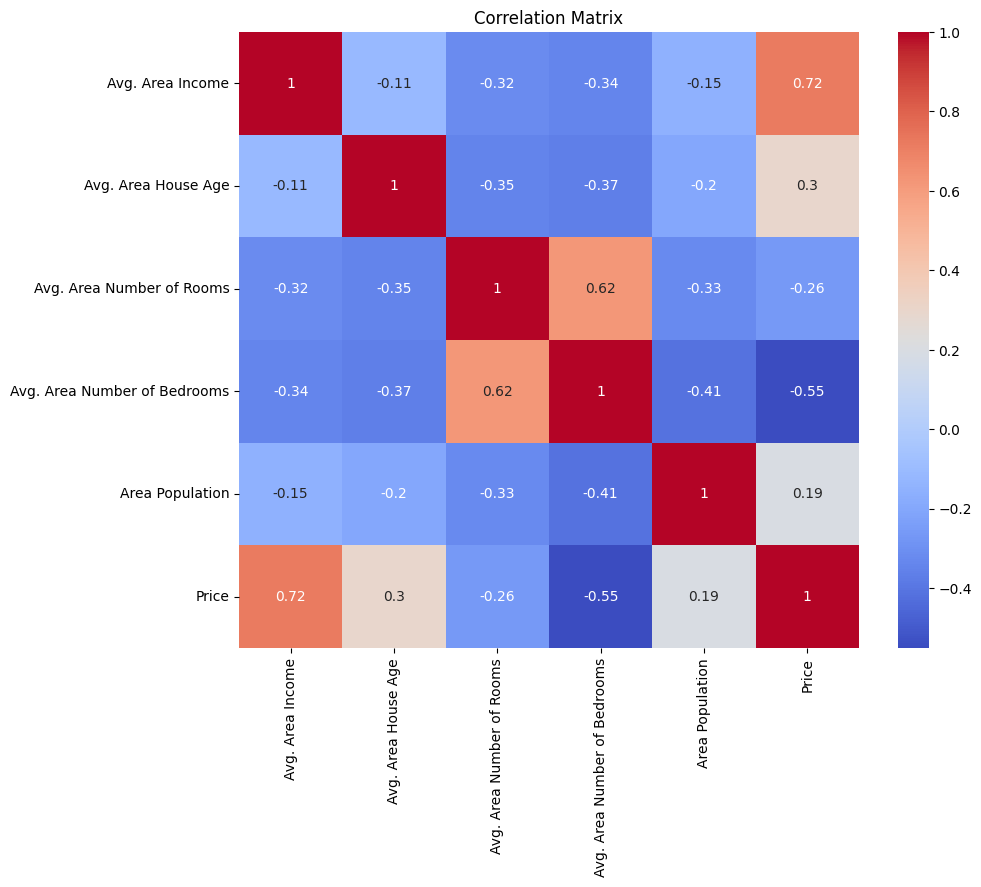

In [17]:
corr_matrix = data.drop('Address', axis=1).corr()
display(Markdown("### <span style='color:#27AE60; font-weight:bold;font-size:24px; text-shadow:0 0 3px rgba(15,52,96,0.6);'>Correlation Heatmap of Numerical Columns</span>"))

plt.figure(figsize=(10,8))

sns.heatmap(corr_matrix.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Matrix")

plt.show()


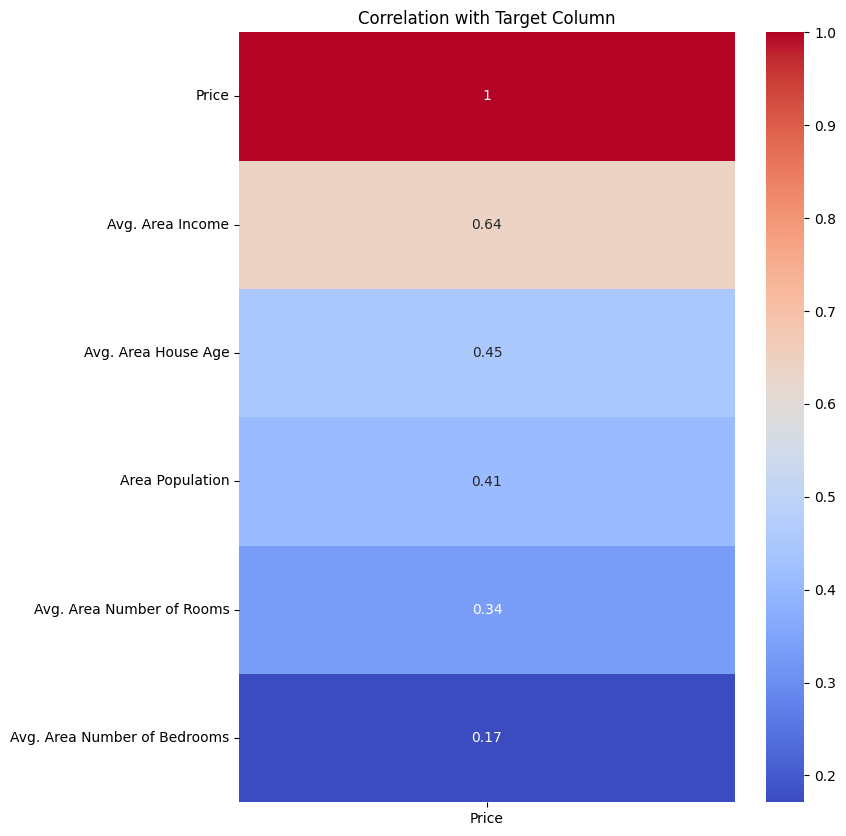

In [18]:
plt.figure(figsize=(8,10))

target_corr = corr_matrix.iloc[:, -1].sort_values(ascending=False)

sns.heatmap(
    target_corr.to_frame(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation with Target Column")

plt.show()

<span style='color:#27AE60; font-weight:bold;font-size:24px; text-shadow:0 0 3px rgba(15,52,96,0.6);'>Key Findings from Correlation Analysis</span>

- All features have positive correlations with the target variable, meaning increases in these features are generally associated with higher house prices.
- No feature demonstrates an extremely high correlation (e.g., above 0.8), indicating that house prices are influenced by a combination of factors rather than a single dominant variable.
- Income has the strongest positive correlation with house price (r = 0.64), indicating that properties located in higher-income areas tend to have higher market values.
- Bedrooms exhibits the weakest correlation with price (r = 0.17), suggesting that the number of bedrooms alone has limited influence on house prices.


# <h2 style= 'text-align:center; color:#27AE60; font-weight:bold;font-size:40px;  text-shadow:0 0 3px rgba(15,52,96,0.6);'>Scatter Plots Analysis!</h2>


### <span style='color:#27AE60; font-weight:bold;font-size:24px; text-shadow:0 0 3px rgba(15,52,96,0.6);'>Scatter Plots: Price vs Each Feature</span>

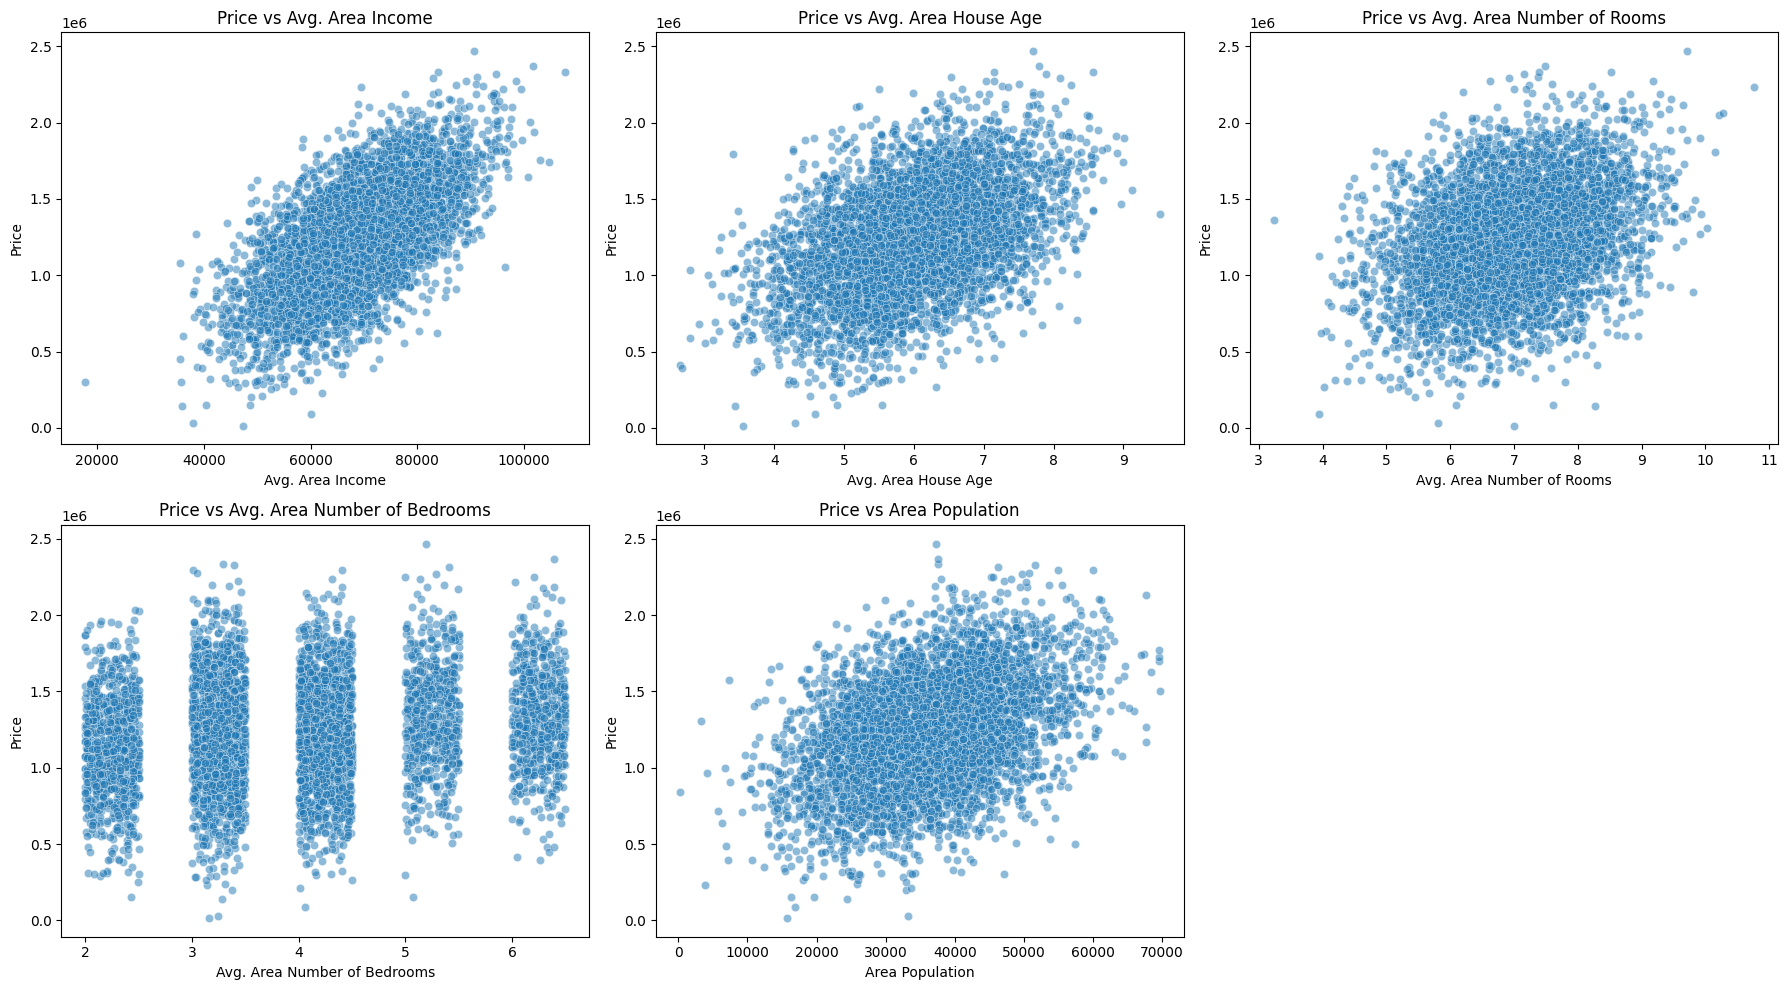

In [19]:
display(Markdown("### <span style='color:#27AE60; font-weight:bold;font-size:24px; text-shadow:0 0 3px rgba(15,52,96,0.6);'>Scatter Plots: Price vs Each Feature</span>"))

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, feature in enumerate(numerical_cols[:-1]):
    sns.scatterplot(
        data=data,
        x=feature,
        y='Price',
        alpha=0.5,
        ax=axes[i]
    )
    axes[i].set_title(f'Price vs {feature}')

# Remove unused subplot
fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

# <h2 style= 'text-align:center; color:#27AE60; font-weight:bold;font-size:40px;  text-shadow:0 0 3px rgba(15,52,96,0.6);'>Key Findings!</h2>

1. Which Features Are Most Important?
- Income is the strongest predictor of house prices.
- House Age, Area Population, and Number of Rooms provide moderate predictive power.
- Number of Bedrooms contributes the least information and may have limited standalone predictive value.
2. Are the Relationships Linear or Non-Linear?
- Scatter plots indicate that most features have approximately linear positive relationships with house price.
- No complex non-linear patterns are evident.
3. Which Features Should Be Used for Modeling?
All numerical features should be included:

- Avg. Area Income
- Avg. Area House Age
- Avg. Area Number of Rooms
- Avg. Area Number of Bedrooms
- Area Population
4. Which Model Types Might Work Best?
<span style='color:#27AE60; font-weight:bold;font-size:14px; text-shadow:0 0 3px rgba(15,52,96,0.6);'>Linear Regression</span>
- Relationships appear mostly linear.
- Target variable is approximately normally distributed.
- Features show moderate correlations with the target.